### 自动微分模块
训练神经网络时，最常用的算法就是反向传播。在该算法中，参数（模型权重）会根据损失函数关于对应参数的梯度进行调整。为了计算这些梯度，PyTorch内置了名维 torch.autograd 的微分模块。它支持任意计算图的自动梯度计算
x -> * -> + -> z -> MSE -> loss
-----↑----↑
-----w----b

使用backward方法、grad属性来实现梯度的计算和访问
Pytorch不支持向量张量对向量张量的求导，只支持标量张量对向量张量的求导
    如果x是张量，y必须是标量才可以进行求导
计算梯度：y.backward(), **y是一个标量**
获取x点的梯度值：x.grad, **会累加上一次的梯度值**

In [6]:
import torch


# 参数1：初始值   参数2：是否自动微分   参数3：数据类型
w = torch.tensor(10, requires_grad=True, dtype=torch.float)

loss = 2 * w ** 2
print(f"梯度函数类型：{loss.grad_fn}")

print(loss.sum())

# 计算完成后，会自动记录到 w.grad 属性中
loss.sum().backward()
alpha = 0.01
# 带入权重更新公式
w.data = w.data - alpha * w.grad
print(f"更新后的w: {w.data}")

梯度函数类型：<MulBackward0 object at 0x0000013B35BAD4E0>
tensor(200., grad_fn=<SumBackward0>)
更新后的w: 9.600000381469727


### 梯度下降法求最优解
1. 梯度下降公式: w = w - alpha * grad
2. 清空上一次的梯度值: w.grad.zero_()

In [13]:
import torch

w = torch.tensor(10, requires_grad=True, dtype=torch.float)
loss = w ** 2 + 20
alpha = 0.01
print(f"开始  权重初始值：{w}, (alpha * w.grad): 无, loss: {loss}")

for i in range(1, 101):
    loss = w ** 2 + 20

    # 第一次还没有计算梯度，所有w.grad = None
    if w.grad is not None:
        w.grad.zero_()

    loss.sum().backward()

    w.data = w.data - alpha * w.grad
    print(f"第{i}次， 权重初始值：{w}, (alpha * w.grad)：{alpha * w.grad：}, loss：{loss}")

print(f"最终结果 权重：{w}, 梯度: {w.grad}, loss: {loss}")

开始  权重初始值：10.0, (alpha * w.grad): 无, loss: 120.0
第1次， 权重初始值：9.800000190734863, (alpha * w.grad)：0.19999998807907104, loss：120.0
第2次， 权重初始值：9.604000091552734, (alpha * w.grad)：0.19599999487400055, loss：116.04000091552734
第3次， 权重初始值：9.411920547485352, (alpha * w.grad)：0.19207999110221863, loss：112.23681640625
第4次， 权重初始值：9.223682403564453, (alpha * w.grad)：0.18823841214179993, loss：108.5842514038086
第5次， 权重初始值：9.03920841217041, (alpha * w.grad)：0.1844736486673355, loss：105.0763168334961
第6次， 权重初始值：8.858424186706543, (alpha * w.grad)：0.1807841658592224, loss：101.70729064941406
第7次， 权重初始值：8.681255340576172, (alpha * w.grad)：0.17716847360134125, loss：98.4716796875
第8次， 权重初始值：8.507630348205566, (alpha * w.grad)：0.17362509667873383, loss：95.36419677734375
第9次， 权重初始值：8.337477684020996, (alpha * w.grad)：0.17015260457992554, loss：92.37977600097656
第10次， 权重初始值：8.170727729797363, (alpha * w.grad)：0.16674955189228058, loss：89.51353454589844
第11次， 权重初始值：8.007312774658203, (alpha * w.grad)：0.163414552

### 梯度计算注意点
不能将自动微分的张量转换成Numpy数组，会发生报错，可以通过detach()方法实现

In [22]:
import torch
import numpy as np

t1 = torch.tensor([10, 20], dtype=torch.float, requires_grad=True)
print(f"t1:{t1}, type:{type(t1)}")

# n1 = t1.numpy()
# print(f"n1:{n1}, type:{type(n1)}")

# 共享内存
t2 = t1.detach()
print(f"t2: {t2}, type:{type(t2)}")
t1.data[0] = 100
print(f"t1:{t1}, type:{type(t1)}")
print(f"t2: {t2}, type:{type(t2)}")

print(f"t1: {t1.requires_grad}, t2: {t2.requires_grad}")
n1 = t2.numpy()
print(f"n1:{n1}, type:{type(n1)}")

n2 = t1.detach().numpy()
print(f"n1:{n2}, type:{type(n2)}")

t1:tensor([10., 20.], requires_grad=True), type:<class 'torch.Tensor'>
t2: tensor([10., 20.]), type:<class 'torch.Tensor'>
t1:tensor([100.,  20.], requires_grad=True), type:<class 'torch.Tensor'>
t2: tensor([100.,  20.]), type:<class 'torch.Tensor'>
t1: True, t2: False
n1:[100.  20.], type:<class 'numpy.ndarray'>
n1:[100.  20.], type:<class 'numpy.ndarray'>


In [27]:
import torch

alpha = 0.01
# 1. 定义特征 x
x = torch.ones(2, 5)
print(f"x: {x}")

# 2. 定义真实值
y = torch.zeros(2, 3)
print(f"y: {y}")

# 3. 初始化权重 和 偏置
w = torch.randn(5, 3, requires_grad=True)
print(f"w: {w}")
b = torch.randn(3, requires_grad=True)
print(f"b: {b}")

# 4. 计算预测值 z
z = x @ w + b
print(f"z: {z}")

# 5. 定义损失函数
criterion = torch.nn.MSELoss()
loss = criterion(z, y)

# 6. 自动微分，求导  结合反向传播，更新权重
loss.sum().backward()

# 7. 打印更新后的 w, b
print(f"w的梯度：{w.grad}")
print(f"b的梯度：{b.grad}")

# 8. 利用公式更新
w.data = w.data - alpha * w.grad
b.data = b.data - alpha * b.grad
print(f"w: {w}")
print(f"b: {b}")

x: tensor([[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]])
y: tensor([[0., 0., 0.],
        [0., 0., 0.]])
w: tensor([[-0.3771,  0.4885,  0.1810],
        [-1.6841, -0.3330, -0.0513],
        [ 0.3951, -0.1739,  0.5435],
        [-1.4937,  1.5376,  0.4502],
        [-1.5832, -0.0461, -0.1752]], requires_grad=True)
b: tensor([-0.2296,  0.4114,  0.2153], requires_grad=True)
z: tensor([[-4.9726,  1.8846,  1.1635],
        [-4.9726,  1.8846,  1.1635]], grad_fn=<AddBackward0>)
w的梯度：tensor([[-3.3151,  1.2564,  0.7757],
        [-3.3151,  1.2564,  0.7757],
        [-3.3151,  1.2564,  0.7757],
        [-3.3151,  1.2564,  0.7757],
        [-3.3151,  1.2564,  0.7757]])
b的梯度：tensor([-3.3151,  1.2564,  0.7757])
w: tensor([[-0.3440,  0.4760,  0.1732],
        [-1.6510, -0.3456, -0.0590],
        [ 0.4282, -0.1865,  0.5357],
        [-1.4606,  1.5251,  0.4424],
        [-1.5501, -0.0587, -0.1829]], requires_grad=True)
b: tensor([-0.1964,  0.3989,  0.2076], requires_grad=True)


### 线性回归案例

<class 'numpy.ndarray'>
轮数: 1, 平均损失值: 1672.7185756138392
轮数: 2, 平均损失值: 1475.060045514788
轮数: 3, 平均损失值: 1331.8573434012276
轮数: 4, 平均损失值: 1226.6925626482282
轮数: 5, 平均损失值: 1130.4717973981585
轮数: 6, 平均损失值: 1035.7405933198474
轮数: 7, 平均损失值: 957.0059387829839
轮数: 8, 平均损失值: 894.9780968257359
轮数: 9, 平均损失值: 835.6336018395803
轮数: 10, 平均损失值: 781.7618807111468
轮数: 11, 平均损失值: 736.0853871927633
轮数: 12, 平均损失值: 692.780458904448
轮数: 13, 平均损失值: 653.4673340346787
轮数: 14, 平均损失值: 619.7773432828942
轮数: 15, 平均损失值: 590.9136425926572
轮数: 16, 平均损失值: 562.2469923155649
轮数: 17, 平均损失值: 536.0254652039343
轮数: 18, 平均损失值: 512.3488981610253
轮数: 19, 平均损失值: 491.1438106594229
轮数: 20, 平均损失值: 471.417074748448
轮数: 21, 平均损失值: 453.59718888470917
轮数: 22, 平均损失值: 437.27358823008353
轮数: 23, 平均损失值: 422.37749469354287
轮数: 24, 平均损失值: 408.28023261115663
轮数: 25, 平均损失值: 395.9104313441685
轮数: 26, 平均损失值: 383.9590661604326
轮数: 27, 平均损失值: 373.2337004040915
轮数: 28, 平均损失值: 362.5457523039409
轮数: 29, 平均损失值: 352.750484064882
轮数: 30, 平均损失值: 343.583

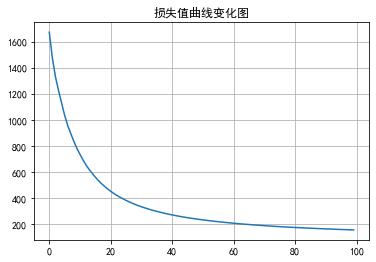

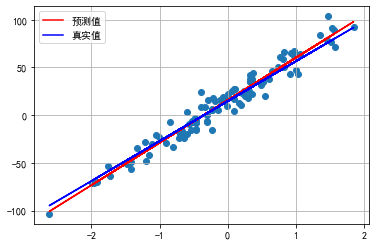

In [47]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from torch import nn, optim
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

def create_dataset():
    x, y, coef = make_regression(
        n_samples=100,  # 样本数量
        n_features = 1,  # 特征数量
        noise = 10,  # 噪声，噪声越大，样本点越分散
        coef = True,   # 是否返回系数，默认False
        bias=14.5,   # 偏置
        random_state = 42,  # 随机数种子
    )
    print(type(x))

    x = torch.tensor(x, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32)

    return x, y, coef

def train(x, y, coef):
    # 创建数据集
    dataset = TensorDataset(x, y)

    # 创建数据加载器对象  参1：数据集对象  参2：批次大小   参3：是否打乱数据(训练集打乱，测试机不打乱)
    dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

    # 创建初始的线性回归模型
    model = nn.Linear(1, 1)

    # 创建损失函数对象
    criterion = nn.MSELoss()

    # 创建优化器对象  参1：模型参数  参2：学习率
    optimizer = optim.SGD(model.parameters(), lr = 0.01)

    # 具体训练过程
    # 1. 定义变量：训练轮数，每轮的（平均）损失值，训练总损失值，训练的样本数
    epochs, loss_list, total_loss, total_sample = 100, [], 0.0, 0
    # 2. 开始训练  按轮训练
    for epoch in range(epochs):
        # 3. 每轮分批次训练，从数据加载器中获取批次数据
        for train_x, train_y in dataloader:
            # 4. 模型预测
            y_pred = model(train_x)
            # 5. 计算损失
            loss = criterion(y_pred, train_y.reshape(-1, 1))  # -1:自动计算  1:1列
            # 6. 计算总损失和样本数
            total_loss += loss.item()
            total_sample += 1
            # 梯度清零 + 反向传播 + 梯度更新
            optimizer.zero_grad()
            loss.sum().backward()
            optimizer.step()

        # 7. 把本轮的平均损失值加入列表中
        loss_list.append(total_loss / total_sample)
        print(f"轮数: {epoch + 1}, 平均损失值: {total_loss / total_sample}")

    # 8. 打印结果
    print(f"100轮的平均损失分别为：{loss_list}")
    print(f"模型参数, 权重: {model.weight.data}, 偏置: {model.bias.data}")

    # 9. 绘制损失曲线
    plt.plot(range(epochs), loss_list)
    plt.title("损失值曲线变化图")
    plt.grid()  # 绘制网格图
    plt.show()

    # 10. 绘制真实值和预测值的关系
    plt.scatter(x, y)
    y_pred = torch.tensor(data = [model.weight * v + model.bias for v in x ])
    y_true = torch.tensor(data = [torch.tensor(coef) * v + 14.5 for v in x])
    plt.plot(x, y_pred, color = 'red', label = '预测值')
    plt.plot(x, y_true, color = 'blue', label = '真实值')
    plt.legend()  # 图例
    plt.grid()
    plt.show()


if __name__ == '__main__':
    x,y,coef = create_dataset()
    # print(f"x: {x}, y: {y}, coef: {coef}")
    # print(f"coef type: {type(coef)}")
    train(x, y, coef)